In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('data_students_performance.csv')

In [4]:
df.shape

(1000, 8)

In [5]:
df.dtypes

gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object

In [6]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [8]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [9]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

<Axes: xlabel='math score'>

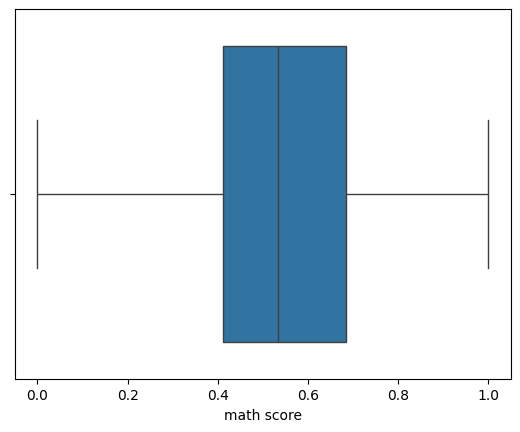

In [22]:
sns.boxplot(x='math score',data=df)

Outliers:
Empty DataFrame
Columns: [gender, race/ethnicity, parental level of education, lunch, test preparation course, math score, reading score, writing score, math score normalized]
Index: []


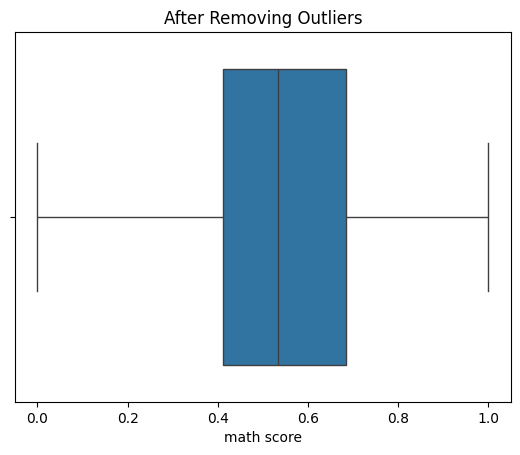

0    0.616438
1    0.575342
2    0.863014
3    0.273973
4    0.671233
Name: math score, dtype: float64


In [20]:
# Z-Score Calculation
z_scores = (df['math score'] - df['math score'].mean()) / df['math score'].std()

# Detect Outliers
outliers = df[(z_scores > 3) | (z_scores < -3)]

print("Outliers:")
print(outliers)

# Remove Outliers
df = df[(z_scores < 3) & (z_scores > -3)]

# Boxplot After Removing Outliers
sns.boxplot(x=df['math score'])
plt.title("After Removing Outliers")
plt.show()

# ======================================
# Normalization
# ======================================

df['math score'] = (
    (df['math score'] - df['math score'].min()) /
    (df['math score'].max() - df['math score'].min())
)

print(df['math score'].head())

<Axes: xlabel='math score', ylabel='Count'>

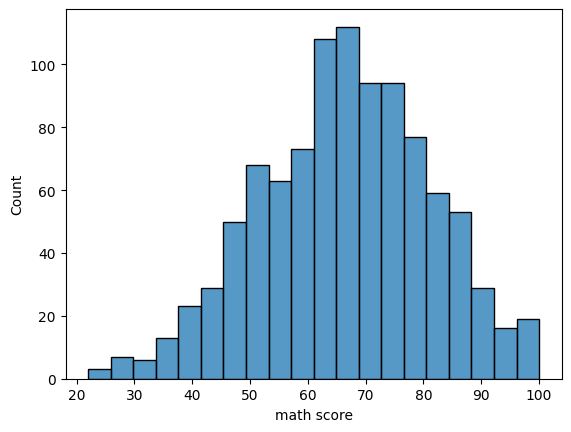

In [14]:
sns.histplot(df['math score'])

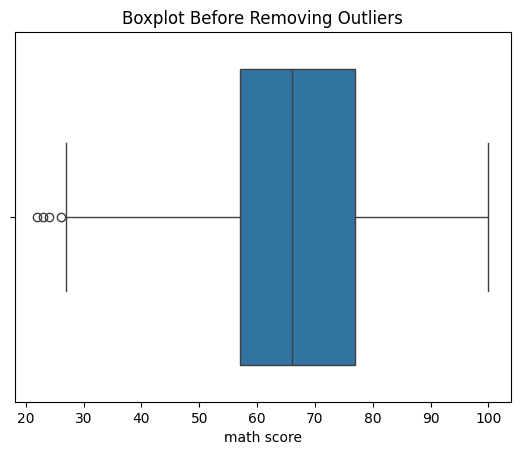

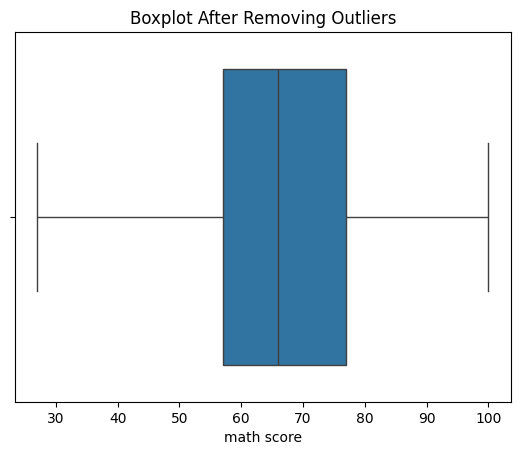

In [16]:
# Boxplot before removing outliers
sns.boxplot(x=df['math score'])
plt.title("Boxplot Before Removing Outliers")
plt.show()

# IQR Method
Q1 = df['math score'].quantile(0.25)
Q3 = df['math score'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

# Remove outliers
df = df[(df['math score'] >= lower_limit) & 
        (df['math score'] <= upper_limit)]

# Boxplot after removing outliers
sns.boxplot(x=df['math score'])
plt.title("Boxplot After Removing Outliers")
plt.show()


<Axes: xlabel='math score', ylabel='Count'>

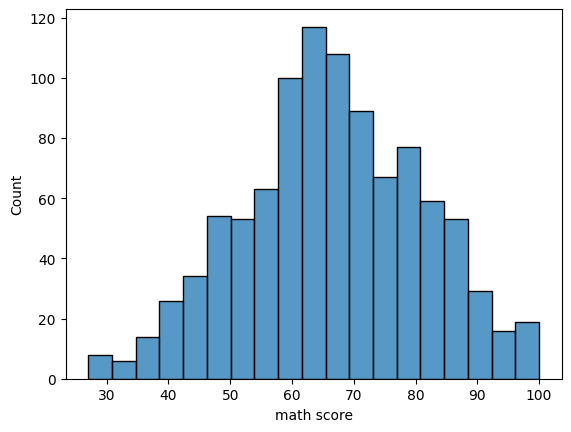

In [18]:
sns.histplot(df['math score'])